
ОЧИЩЕННЫЕ ТЕКСТЫ

[0]
Исходный : Клиент не может войти в личный кабинет после смены пароля
Очищенный: войти личный кабинет после смены пароля

[1]
Исходный : Не получается авторизоваться в личном кабинете, пароль не принимается
Очищенный: получается авторизоваться личном кабинете пароль принимается

[2]
Исходный : Пользователь забыл пароль и не может войти в аккаунт
Очищенный: пользователь забыл пароль войти аккаунт

[3]
Исходный : После изменения пароля клиент не может выполнить вход
Очищенный: после изменения пароля выполнить вход

[4]
Исходный : Ошибка авторизации при входе в личный кабинет
Очищенный: ошибка авторизации входе личный кабинет

[5]
Исходный : Не проходит оплата банковской картой
Очищенный: проходит оплата банковской картой

[6]
Исходный : Клиент не может оплатить заказ картой
Очищенный: оплатить заказ картой

[7]
Исходный : Ошибка при оплате банковской картой
Очищенный: ошибка оплате банковской картой

[8]
Исходный : Платеж картой отклонен при оформлении заказа
Очищен

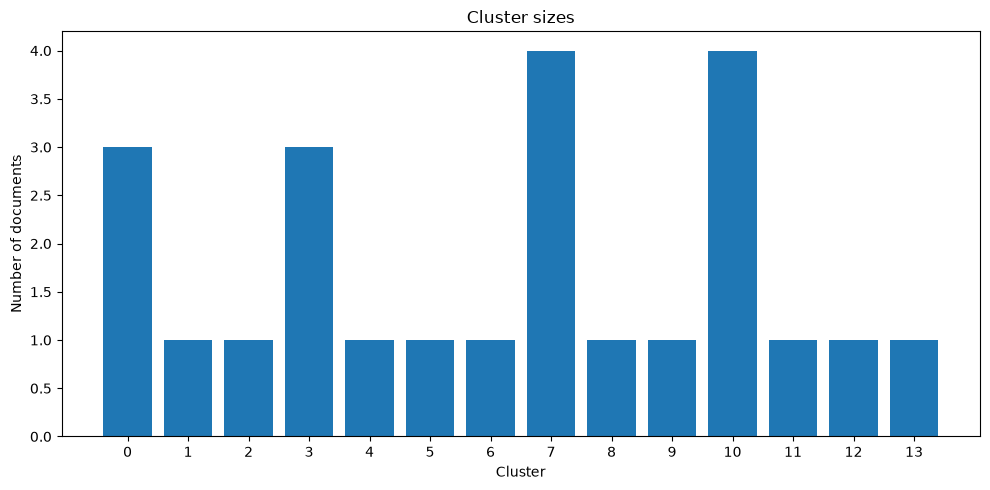

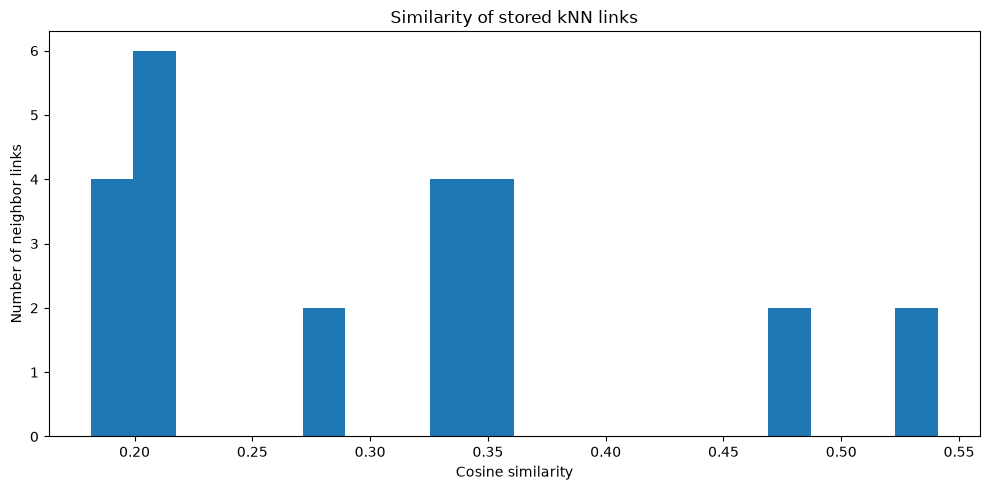

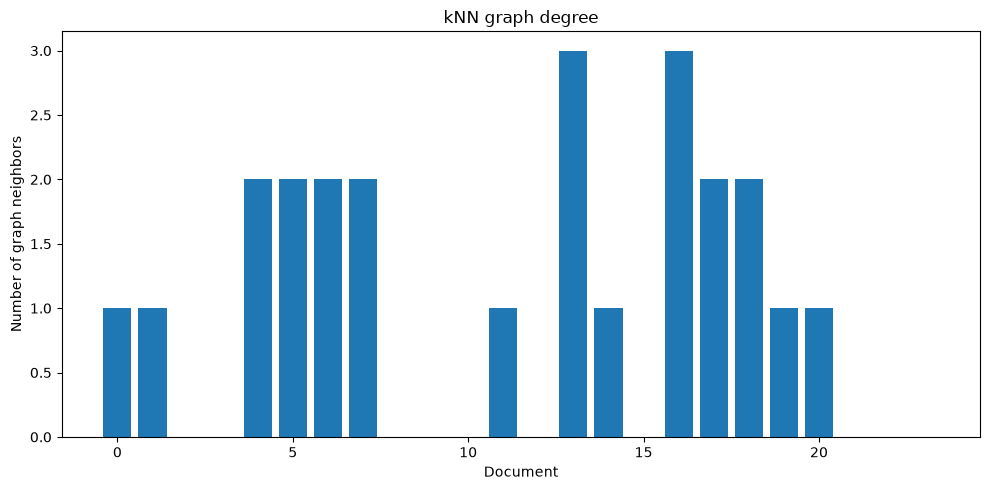

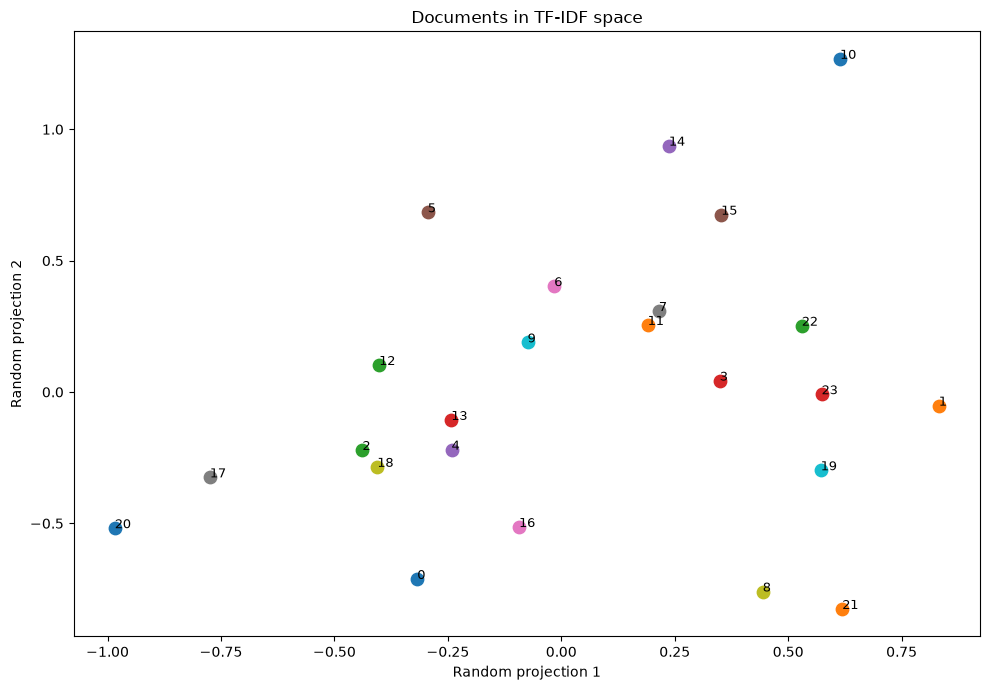

In [2]:
import re
import math
import random
from collections import Counter, defaultdict

import matplotlib.pyplot as plt


# ============================================================
# 1. НАСТРОЙКИ
# ============================================================

# Word n-grams
WORD_NGRAM_RANGE = (1, 2)

# Character n-grams
CHAR_NGRAM_RANGE = (3, 5)

# Вес признаков
WORD_WEIGHT = 1.0
CHAR_WEIGHT = 1.2       # <-- увеличили вклад char n-grams

# k ближайших соседей
TOP_K_NEIGHBORS = 4

# Минимальное сходство для попадания в kNN-граф
MIN_SIMILARITY = 0.18

# Очистка
MIN_TOKEN_LEN = 2
REMOVE_NUMBERS = True

# Удалять слова, которые встречаются более чем
# в этой доле документов.
#
# Например:
# 0.85 -> убрать слова, встречающиеся > 85% документов
MAX_DOC_FRACTION = 0.85

RANDOM_SEED = 42


# ============================================================
# 2. ТЕСТОВЫЕ ДАННЫЕ
# ============================================================

texts = [
    # --- Логин / пароль ---
    "Клиент не может войти в личный кабинет после смены пароля",
    "Не получается авторизоваться в личном кабинете, пароль не принимается",
    "Пользователь забыл пароль и не может войти в аккаунт",
    "После изменения пароля клиент не может выполнить вход",
    "Ошибка авторизации при входе в личный кабинет",

    # --- Оплата / карта ---
    "Не проходит оплата банковской картой",
    "Клиент не может оплатить заказ картой",
    "Ошибка при оплате банковской картой",
    "Платеж картой отклонен при оформлении заказа",
    "Не удается провести оплату по карте",

    # --- Доставка ---
    "Клиент не получил заказ в указанный срок",
    "Заказ задерживается, доставка еще не выполнена",
    "Посылка не пришла в ожидаемую дату",
    "Задержка доставки заказа клиенту",
    "Когда будет доставлен мой заказ",

    # --- Возврат ---
    "Как вернуть товар и получить деньги обратно",
    "Клиент хочет оформить возврат товара",
    "Необходимо вернуть заказ и оформить возврат средств",
    "Как оформить возврат покупки",
    "Возврат товара после получения заказа",

    # --- Другие обращения ---
    "Хочу изменить адрес доставки для заказа",
    "Как поменять номер телефона в профиле",
    "Приложение закрывается при запуске",
    "Не приходит код подтверждения на телефон",
]


# ============================================================
# 3. STOP WORDS
# ============================================================

# ------------------------------------------------------------
# Базовые стоп-слова.
#
# Это слова, которые обычно мало полезны для кластеризации
# независимо от предметной области.
# ------------------------------------------------------------

BASE_STOP_WORDS = {
    "и", "или", "а", "но", "да", "не", "ни",

    "в", "во",
    "на",
    "за",
    "из",
    "к", "ко",
    "с", "со",
    "у",
    "о", "об",
    "от",
    "до",
    "по",
    "при",
    "для",
    "про",
    "через",

    "это",
    "этот",
    "эта",
    "эти",
    "тот",
    "та",
    "те",

    "как",
    "что",
    "чтобы",
    "если",

    "я",
    "мы",
    "ты",
    "вы",
    "он",
    "она",
    "они",

    "мне",
    "меня",
    "ему",
    "ей",
    "им",
    "их",

    "мой",
    "моя",
    "мое",
    "мои",

    "твой",
    "твоя",
    "твое",
    "твои",

    "ваш",
    "ваша",
    "ваше",
    "ваши",

    "наш",
    "наша",
    "наше",
    "наши",

    "бы",
    "же",
    "ли",

    "был",
    "была",
    "было",
    "были",

    "будет",
    "будут",

    "есть",

    "может",
    "могу",
    "можно",
    "нужно",

    "хочу",
    "хотел",
    "хотела",
}


# ------------------------------------------------------------
# Доменные стоп-слова.
#
# СЮДА ТЫ ДОБАВЛЯЕШЬ СВОИ СЛОВА.
#
# Например, если в твоем корпусе почти каждый текст содержит:
#
# "клиент", "заявка", "обращение", "система"
#
# их можно добавить сюда.
# ------------------------------------------------------------

DOMAIN_STOP_WORDS = {
    "клиент",
    # "заявка",
    # "обращение",
    # "система",
}


# Объединяем их только здесь.
STOP_WORDS = BASE_STOP_WORDS | DOMAIN_STOP_WORDS


# ============================================================
# 4. ТОКЕНИЗАЦИЯ
# ============================================================

TOKEN_RE = re.compile(
    r"[а-яёa-z0-9]+",
    re.IGNORECASE
)


def tokenize(text):
    """
    Приводим текст к нижнему регистру
    и выделяем слова/числа.
    """

    text = text.lower()

    # ё -> е, чтобы:
    # платеж / платёж
    # не становились разными словами
    text = text.replace("ё", "е")

    return TOKEN_RE.findall(text)


# ============================================================
# 5. ОЧИСТКА ТЕКСТА
# ============================================================

def clean_text(
    text,
    stop_words=STOP_WORDS,
    min_token_len=MIN_TOKEN_LEN,
    remove_numbers=REMOVE_NUMBERS,
):
    tokens = tokenize(text)

    result = []

    for token in tokens:

        # короткие токены
        if len(token) < min_token_len:
            continue

        # стоп-слова
        if token in stop_words:
            continue

        # числа
        if remove_numbers and token.isdigit():
            continue

        result.append(token)

    return result


def clean_corpus(texts):
    return [
        clean_text(text)
        for text in texts
    ]


# ============================================================
# 6. СЛИШКОМ ЧАСТЫЕ СЛОВА
# ============================================================

def find_common_words(
    tokenized_texts,
    max_doc_fraction=MAX_DOC_FRACTION,
):
    """
    Находим слова, встречающиеся почти во всех документах.

    Это отдельный механизм от STOP_WORDS.

    Например, если "клиент" есть в 95% документов,
    его можно автоматически исключить.
    """

    n_docs = len(tokenized_texts)

    document_frequency = Counter()

    for tokens in tokenized_texts:
        document_frequency.update(set(tokens))

    common_words = {
        word
        for word, count in document_frequency.items()
        if count / n_docs > max_doc_fraction
    }

    return common_words, document_frequency


def remove_common_words(
    tokenized_texts,
    common_words,
):
    return [
        [
            token
            for token in tokens
            if token not in common_words
        ]
        for tokens in tokenized_texts
    ]


# ============================================================
# 7. WORD N-GRAMS
# ============================================================

def word_ngrams(
    tokens,
    ngram_range=WORD_NGRAM_RANGE,
):
    result = []

    min_n, max_n = ngram_range

    for n in range(min_n, max_n + 1):

        for i in range(
            len(tokens) - n + 1
        ):
            result.append(
                " ".join(
                    tokens[i:i + n]
                )
            )

    return result


# ============================================================
# 8. CHARACTER N-GRAMS
# ============================================================

def char_ngrams(
    text,
    ngram_range=CHAR_NGRAM_RANGE,
):
    """
    Character n-grams.

    Например:

        "пароль"

    может дать:

        "пар"
        "аро"
        "рол"
        "оль"

    и более длинные последовательности.

    Они позволяют частично компенсировать проблему
    разных окончаний русских слов:

        карта
        картой
        карте

    """

    text = " ".join(text.split())

    result = []

    min_n, max_n = ngram_range

    for n in range(min_n, max_n + 1):

        for i in range(
            len(text) - n + 1
        ):
            result.append(
                text[i:i + n]
            )

    return result


# ============================================================
# 9. СОЗДАНИЕ ПРИЗНАКОВ
# ============================================================

def build_feature_documents(
    tokenized_texts,
):
    documents = []

    for tokens in tokenized_texts:

        features = Counter()

        # ----------------------------------------------------
        # WORD FEATURES
        # ----------------------------------------------------

        words = word_ngrams(tokens)

        for feature in words:

            features[
                "W:" + feature
            ] += WORD_WEIGHT

        # ----------------------------------------------------
        # CHAR FEATURES
        # ----------------------------------------------------

        cleaned_text = " ".join(tokens)

        chars = char_ngrams(
            cleaned_text
        )

        for feature in chars:

            features[
                "C:" + feature
            ] += CHAR_WEIGHT

        documents.append(features)

    return documents


# ============================================================
# 10. TF-IDF
# ============================================================

def tfidf_sparse(
    feature_documents,
):
    """
    TF-IDF в виде sparse dict.

    Например:

        {
            "W:пароль": 0.31,
            "C:аро": 0.17,
            ...
        }

    """

    n_docs = len(feature_documents)

    document_frequency = Counter()

    for document in feature_documents:

        for feature in document:
            document_frequency[feature] += 1

    vectors = []

    for document in feature_documents:

        vector = {}

        for feature, tf in document.items():

            df = document_frequency[feature]

            idf = (
                math.log(
                    (1 + n_docs) /
                    (1 + df)
                )
                + 1.0
            )

            vector[feature] = (
                tf * idf
            )

        # L2 normalization
        norm = math.sqrt(
            sum(
                value * value
                for value in vector.values()
            )
        )

        if norm > 0:

            for feature in vector:
                vector[feature] /= norm

        vectors.append(vector)

    return vectors, document_frequency


# ============================================================
# 11. COSINE SIMILARITY
# ============================================================

def cosine_similarity(
    vec_a,
    vec_b,
):
    """
    Векторы уже L2-нормализованы,
    поэтому cosine = dot product.
    """

    # Итерируемся по меньшему словарю.
    if len(vec_a) > len(vec_b):
        vec_a, vec_b = vec_b, vec_a

    score = 0.0

    for feature, value in vec_a.items():

        other = vec_b.get(feature)

        if other is not None:
            score += value * other

    return score


# ============================================================
# 12. INVERTED INDEX
# ============================================================

def build_inverted_index(
    vectors,
):
    """
    feature -> документы,
    в которых он присутствует.

    Благодаря этому не нужно сравнивать каждый документ
    с абсолютно каждым.
    """

    inverted = defaultdict(set)

    for doc_id, vector in enumerate(vectors):

        for feature in vector:
            inverted[feature].add(doc_id)

    return inverted


# ============================================================
# 13. TOP-K NEAREST NEIGHBORS
# ============================================================

def top_k_neighbors(
    vectors,
    k=TOP_K_NEIGHBORS,
    min_similarity=MIN_SIMILARITY,
):
    """
    Для каждого документа сохраняем только K лучших соседей.

    ВСЕ пары здесь не хранятся.

    Возвращаем:

        neighbors[i] = [
            (similarity, document_id),
            ...
        ]
    """

    n = len(vectors)

    inverted = build_inverted_index(
        vectors
    )

    neighbors = [
        []
        for _ in range(n)
    ]

    for i in range(n):

        # ----------------------------------------------------
        # Получаем кандидатов через общие признаки.
        # ----------------------------------------------------

        candidates = set()

        for feature in vectors[i]:

            candidates.update(
                inverted[feature]
            )

        candidates.discard(i)

        # ----------------------------------------------------
        # Считаем cosine только для кандидатов.
        # ----------------------------------------------------

        scores = []

        for j in candidates:

            similarity = cosine_similarity(
                vectors[i],
                vectors[j],
            )

            if similarity >= min_similarity:

                scores.append(
                    (
                        similarity,
                        j,
                    )
                )

        # ----------------------------------------------------
        # Оставляем только K лучших.
        # ----------------------------------------------------

        scores.sort(
            reverse=True
        )

        neighbors[i] = scores[:k]

    return neighbors


# ============================================================
# 14. KNN GRAPH
# ============================================================

def build_knn_graph(
    neighbors,
):
    """
    Делаем симметричный граф.

    Если:

        A -> B

    то добавляем:

        A -- B

    даже если B не включил A в свой top-K.
    """

    graph = defaultdict(set)

    for i, items in enumerate(
        neighbors
    ):

        for similarity, j in items:

            graph[i].add(j)
            graph[j].add(i)

    return graph


# ============================================================
# 15. CONNECTED COMPONENTS
# ============================================================

def connected_components(
    graph,
    n_docs,
):
    """
    Каждая connected component = кластер.

    Важно:

        A -- B -- C

    A и C не обязаны быть похожи напрямую.

    Достаточно цепочки соседей.
    """

    visited = set()

    clusters = []

    for start in range(n_docs):

        if start in visited:
            continue

        stack = [start]

        visited.add(start)

        cluster = []

        while stack:

            node = stack.pop()

            cluster.append(node)

            for neighbor in graph[node]:

                if neighbor not in visited:

                    visited.add(neighbor)

                    stack.append(neighbor)

        clusters.append(
            sorted(cluster)
        )

    return clusters


# ============================================================
# 16. TOP FEATURES
# ============================================================

def cluster_top_features(
    cluster,
    vectors,
    top_n=10,
):
    counter = Counter()

    for doc_id in cluster:

        for feature, value in vectors[
            doc_id
        ].items():

            counter[feature] += value

    return counter.most_common(
        top_n
    )


# ============================================================
# 17. ВЫВОД ОЧИЩЕННЫХ ТЕКСТОВ
# ============================================================

def print_cleaned_texts(
    original_texts,
    cleaned_tokens,
):
    print("\n" + "=" * 80)
    print("ОЧИЩЕННЫЕ ТЕКСТЫ")
    print("=" * 80)

    for i, (
        original,
        tokens,
    ) in enumerate(
        zip(
            original_texts,
            cleaned_tokens,
        )
    ):

        print(f"\n[{i}]")
        print(
            "Исходный :",
            original,
        )

        print(
            "Очищенный:",
            " ".join(tokens),
        )


# ============================================================
# 18. ВЫВОД СОСЕДЕЙ
# ============================================================

def print_neighbors(
    texts,
    neighbors,
):
    print("\n" + "=" * 80)
    print("TOP-K СОСЕДИ")
    print("=" * 80)

    for i, items in enumerate(
        neighbors
    ):

        print(
            f"\n[{i}] {texts[i]}"
        )

        if not items:

            print(
                "  нет соседей"
            )

            continue

        for similarity, j in items:

            print(
                f"  {similarity:.3f}"
                f" -> [{j}] "
                f"{texts[j]}"
            )


# ============================================================
# 19. ВЫВОД КЛАСТЕРОВ
# ============================================================

def print_clusters(
    texts,
    clusters,
):
    print("\n" + "=" * 80)
    print("КЛАСТЕРЫ")
    print("=" * 80)

    for cluster_id, cluster in enumerate(
        clusters
    ):

        print(
            f"\nКластер {cluster_id} "
            f"({len(cluster)} документов)"
        )

        for doc_id in cluster:

            print(
                f"  [{doc_id}] "
                f"{texts[doc_id]}"
            )


# ============================================================
# 20. ВЫВОД ХАРАКТЕРНЫХ ПРИЗНАКОВ
# ============================================================

def print_cluster_features(
    clusters,
    vectors,
):
    print("\n" + "=" * 80)
    print("ХАРАКТЕРНЫЕ ПРИЗНАКИ КЛАСТЕРОВ")
    print("=" * 80)

    for cluster_id, cluster in enumerate(
        clusters
    ):

        print(
            f"\nКластер {cluster_id}:"
        )

        for feature, score in cluster_top_features(
            cluster,
            vectors,
        ):

            feature_type = feature[:2]
            value = feature[2:]

            print(
                f"  {feature_type} "
                f"{value:<35} "
                f"{score:.3f}"
            )


# ============================================================
# 21. ВИЗУАЛИЗАЦИЯ: РАЗМЕРЫ КЛАСТЕРОВ
# ============================================================

def plot_cluster_sizes(
    clusters,
):
    sizes = [
        len(cluster)
        for cluster in clusters
    ]

    plt.figure(
        figsize=(10, 5)
    )

    plt.bar(
        range(len(sizes)),
        sizes,
    )

    plt.xlabel("Cluster")
    plt.ylabel(
        "Number of documents"
    )

    plt.title(
        "Cluster sizes"
    )

    plt.xticks(
        range(len(sizes))
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 22. ВИЗУАЛИЗАЦИЯ: SIMILARITY
# ============================================================

def plot_neighbor_similarity(
    neighbors,
):
    values = []

    for items in neighbors:

        for similarity, _ in items:
            values.append(
                similarity
            )

    if not values:
        return

    plt.figure(
        figsize=(10, 5)
    )

    plt.hist(
        values,
        bins=20,
    )

    plt.xlabel(
        "Cosine similarity"
    )

    plt.ylabel(
        "Number of neighbor links"
    )

    plt.title(
        "Similarity of stored kNN links"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 23. ВИЗУАЛИЗАЦИЯ: СТЕПЕНЬ ВЕРШИН
# ============================================================

def plot_document_degree(
    graph,
    n_docs,
):
    degrees = [
        len(graph[i])
        for i in range(n_docs)
    ]

    plt.figure(
        figsize=(10, 5)
    )

    plt.bar(
        range(n_docs),
        degrees,
    )

    plt.xlabel(
        "Document"
    )

    plt.ylabel(
        "Number of graph neighbors"
    )

    plt.title(
        "kNN graph degree"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 24. 2D RANDOM PROJECTION
# ============================================================

def plot_random_projection(
    vectors,
    clusters,
):
    random.seed(
        RANDOM_SEED
    )

    features = sorted({
        feature
        for vector in vectors
        for feature in vector
    })

    direction_x = {
        feature: random.uniform(
            -1,
            1,
        )
        for feature in features
    }

    direction_y = {
        feature: random.uniform(
            -1,
            1,
        )
        for feature in features
    }

    xs = []
    ys = []

    for vector in vectors:

        x = sum(
            value *
            direction_x[feature]
            for feature, value
            in vector.items()
        )

        y = sum(
            value *
            direction_y[feature]
            for feature, value
            in vector.items()
        )

        xs.append(x)
        ys.append(y)

    plt.figure(
        figsize=(10, 7)
    )

    for doc_id in range(
        len(vectors)
    ):

        plt.scatter(
            xs[doc_id],
            ys[doc_id],
            s=80,
        )

        plt.text(
            xs[doc_id],
            ys[doc_id],
            str(doc_id),
            fontsize=9,
        )

    plt.xlabel(
        "Random projection 1"
    )

    plt.ylabel(
        "Random projection 2"
    )

    plt.title(
        "Documents in TF-IDF space"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 25. ОСНОВНОЙ PIPELINE
# ============================================================

def cluster_texts(
    texts,
    top_k=TOP_K_NEIGHBORS,
    min_similarity=MIN_SIMILARITY,
    max_doc_fraction=MAX_DOC_FRACTION,
):
    # --------------------------------------------------------
    # STEP 1. Очистка
    # --------------------------------------------------------

    tokenized = clean_corpus(
        texts
    )

    # --------------------------------------------------------
    # STEP 2. Удаляем слишком частые слова
    # --------------------------------------------------------

    common_words, document_frequency = find_common_words(
        tokenized,
        max_doc_fraction,
    )

    tokenized = remove_common_words(
        tokenized,
        common_words,
    )

    # --------------------------------------------------------
    # STEP 3. Word + Char n-grams
    # --------------------------------------------------------

    feature_documents = build_feature_documents(
        tokenized
    )

    # --------------------------------------------------------
    # STEP 4. TF-IDF
    # --------------------------------------------------------

    vectors, feature_df = tfidf_sparse(
        feature_documents
    )

    # --------------------------------------------------------
    # STEP 5. Top-K nearest neighbors
    # --------------------------------------------------------

    neighbors = top_k_neighbors(
        vectors,
        k=top_k,
        min_similarity=min_similarity,
    )

    # --------------------------------------------------------
    # STEP 6. kNN graph
    # --------------------------------------------------------

    graph = build_knn_graph(
        neighbors
    )

    # --------------------------------------------------------
    # STEP 7. Clustering
    # --------------------------------------------------------

    clusters = connected_components(
        graph,
        len(texts),
    )

    return {
        "cleaned_tokens": tokenized,

        "common_words": common_words,

        "document_frequency":
            document_frequency,

        "vectors": vectors,

        "feature_df":
            feature_df,

        "neighbors":
            neighbors,

        "graph":
            graph,

        "clusters":
            clusters,
    }


# ============================================================
# 26. ЗАПУСК
# ============================================================

result = cluster_texts(
    texts,

    top_k=TOP_K_NEIGHBORS,

    min_similarity=MIN_SIMILARITY,

    max_doc_fraction=MAX_DOC_FRACTION,
)


# ============================================================
# 27. РЕЗУЛЬТАТЫ
# ============================================================

print_cleaned_texts(
    texts,
    result["cleaned_tokens"],
)


print("\n" + "=" * 80)
print("BASE STOP WORDS")
print("=" * 80)

print(
    ", ".join(
        sorted(BASE_STOP_WORDS)
    )
)


print("\n" + "=" * 80)
print("DOMAIN STOP WORDS")
print("=" * 80)

if DOMAIN_STOP_WORDS:
    print(
        ", ".join(
            sorted(DOMAIN_STOP_WORDS)
        )
    )
else:
    print("(пусто)")


print("\n" + "=" * 80)
print("АВТОМАТИЧЕСКИ УДАЛЕННЫЕ ЧАСТОТНЫЕ СЛОВА")
print("=" * 80)

if result["common_words"]:

    print(
        ", ".join(
            sorted(
                result["common_words"]
            )
        )
    )

else:

    print("(нет)")


print_neighbors(
    texts,
    result["neighbors"],
)


print_clusters(
    texts,
    result["clusters"],
)


print_cluster_features(
    result["clusters"],
    result["vectors"],
)


# ============================================================
# 28. ГРАФИКИ
# ============================================================

plot_cluster_sizes(
    result["clusters"]
)

plot_neighbor_similarity(
    result["neighbors"]
)

plot_document_degree(
    result["graph"],
    len(texts),
)

plot_random_projection(
    result["vectors"],
    result["clusters"],
)